# Problems: Apply a Planar-Truss Grammar by Hand

This notebook treats a grammar problem as a sequence of explicit state transitions.
We start from the packaged planar-truss seed, inspect all legal rules, and manually
apply three `add_member` rules to construct a triangle. No solver or optional truss
analysis package is required.

## Setup

```bash
python -m pip install design-research-problems==0.4.0 matplotlib
```

Open the notebook in VS Code, select that environment as the kernel, and run each cell
in order.

## Step 1: Load the grammar and its immutable seed state

In [1]:
from collections import Counter

import design_research_problems as problems
import matplotlib.pyplot as plt

grammar = problems.get_problem_as("planar_truss_span", problems.GrammarProblem)
seed_state = grammar.initial_state()
state = seed_state
print("Grammar:", type(grammar).__name__)
print("Problem:", grammar.metadata.title)
print(f"Seed state: {len(state.joints)} joints, {len(state.members)} members")

Grammar: PlanarTrussSpanProblem
Problem: Planar truss span grammar problem
Seed state: 3 joints, 0 members


## Step 2: Inspect the starting geometry

The seed already has a pinned support, a roller support, and one loaded free joint.
The grammar state is serializable data; rule application returns a new state rather
than mutating this object.

In [2]:
for joint in state.joints:
    print(f"joint {joint.joint_id}: ({joint.x:.1f}, {joint.y:.1f}), support={joint.support_type}")
print("Load joint:", state.load_joint_id)
print("Load vector:", state.load_vector)

joint 0: (0.0, 0.0), support=pinned
joint 1: (10.0, 0.0), support=roller
joint 2: (5.0, 5.0), support=free
Load joint: 2
Load vector: (0.0, -1000.0, 0.0)


## Step 3: Enumerate the legal rule applications

In [3]:
transitions = grammar.enumerate_transitions(state)
rule_counts = Counter(transition.rule_name for transition in transitions)
print("Legal transitions:", len(transitions))
print("Rule counts:", dict(sorted(rule_counts.items())))
for transition in transitions:
    print(f"- {transition.rule_name}: {dict(transition.parameters)}")

Legal transitions: 6
Rule counts: {'add_joint': 3, 'add_member': 3}
- add_joint: {'x': 2.5, 'y': 2.5}
- add_joint: {'x': 5.0, 'y': 2.5}
- add_joint: {'x': 7.5, 'y': 2.5}
- add_member: {'start_joint_id': 0, 'end_joint_id': 1}
- add_member: {'start_joint_id': 0, 'end_joint_id': 2}
- add_member: {'start_joint_id': 1, 'end_joint_id': 2}


## Step 4: Add the left web member

We apply the public rule method directly, using the joint IDs observed above.

In [4]:
state = grammar.add_member(state, start_joint_id=0, end_joint_id=2)
print("Members after rule 1:", [(m.start_joint_id, m.end_joint_id) for m in state.members])
print("Seed members remain:", len(seed_state.members))

Members after rule 1: [(0, 2)]
Seed members remain: 0


## Step 5: Add the right web member

In [5]:
state = grammar.add_member(state, start_joint_id=1, end_joint_id=2)
print("Members after rule 2:", [(m.start_joint_id, m.end_joint_id) for m in state.members])

Members after rule 2: [(0, 2), (1, 2)]


## Step 6: Close the base and draw the resulting state

Final state: 3 joints, 3 members


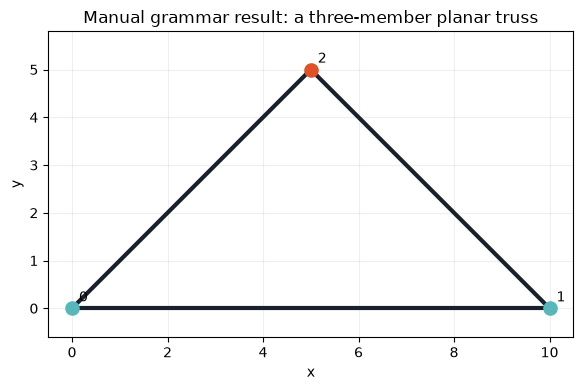

In [6]:
state = grammar.add_member(state, start_joint_id=0, end_joint_id=1)
joint_lookup = {joint.joint_id: joint for joint in state.joints}
figure, axis = plt.subplots(figsize=(8, 4))
for member in state.members:
    start = joint_lookup[member.start_joint_id]
    end = joint_lookup[member.end_joint_id]
    axis.plot([start.x, end.x], [start.y, end.y], color="#18212b", linewidth=3)
for joint in state.joints:
    axis.scatter(
        joint.x,
        joint.y,
        s=90,
        color="#df5127" if joint.support_type == "free" else "#57b7ba",
        zorder=3,
    )
    axis.annotate(
        str(joint.joint_id), (joint.x, joint.y), xytext=(5, 5), textcoords="offset points"
    )
axis.set(
    title="Manual grammar result: a three-member planar truss",
    xlabel="x",
    ylabel="y",
    aspect="equal",
)
axis.set_ylim(-0.6, state.max_height + 0.8)
axis.grid(alpha=0.2)
figure.tight_layout()
print(f"Final state: {len(state.joints)} joints, {len(state.members)} members")
plt.show()

## Step 7: Ask the grammar what can happen next

The completed triangle is not a terminal state. Legal edits still include candidate
joint additions and member removals, which makes the same API suitable for manual,
algorithmic, or agent-driven exploration.

In [7]:
next_transitions = grammar.enumerate_transitions(state)
next_rule_counts = Counter(transition.rule_name for transition in next_transitions)
print("Next legal transitions:", len(next_transitions))
print("Next rule counts:", dict(sorted(next_rule_counts.items())))

Next legal transitions: 6
Next rule counts: {'add_joint': 3, 'remove_member': 3}
